# Notebook 6.6: Thực hành Huấn luyện BiLSTM - Mạng Bộ Nhớ Ngắn Hạn Đảo Chiều (WSI + Genomics)
---
## 🎯 Mục đích của Notebook (Dùng để Trình chiếu & Bảo vệ)
Notebook này được thiết kế để giải quyết dứt điểm yêu cầu của Hội đồng: **"Phải có ứng dụng mạng LSTM trong xử lý dữ liệu"**.

Tuy nhiên, chúng ta không dùng LSTM một cách khiên cưỡng. Chúng ta sử dụng **BiLSTM (Bidirectional LSTM)** để xử lý hình ảnh WSI theo một triết lý Y Sinh cực kỳ chặt chẽ:
- Một tấm lam kính (WSI) của bệnh nhân quá to, chứa hàng tỷ pixel. Ta phải cắt nó thành hàng ngàn bản vá (patches).
- Hàng ngàn bản vá này được sắp xếp thành một **"Chuỗi không gian" (Spatial Sequence)**.
- Mạng **Bi-LSTM** sẽ trượt qua chuỗi ảnh này từ trái sang phải, rồi lại từ phải sang trái (2 chiều). Nó đóng vai trò như một **"Máy Quét Bệnh Lý"**, ghi nhớ (Memory) các tế bào ác tính xuất hiện dọc theo mặt kính, sau đó tổng hợp lại thành 1 kết luận duy nhất cho toàn bộ khối u.

Notebook này được chia nhỏ từng phần (Layer-by-Layer), giải thích **TỪNG THAM SỐ CODE** để bạn dùng làm "phao cứu sinh" khi bị Giảng viên Phản biện hỏi xoáy.

In [1]:
# Khai báo các thư viện thiết yếu
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# CẤU HÌNH FONT TIẾNG VIỆT QUỐC DÂN CHO MATPLOTLIB
# (Chống lỗi font hiển thị hình ô vuông trên Kaggle/Windows)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("✓ Khởi tạo môi trường hoàn tất!")

✓ Khởi tạo môi trường hoàn tất!


## 1. Nạp Dữ Liệu (Genomics & Clinical)
Ở bước này, ta nạp dữ liệu Gen RNA-Seq. Bảng gốc có 20,500 gen, nếu đưa thẳng vào AI sẽ gây ra **"Lời nguyền số chiều" (Curse of Dimensionality)**, khiến mô hình học vẹt (Overfit).

**Cách giải quyết:** Áp dụng thuật toán **Variance Threshold** để chọn ra đúng 500 gen có phương sai (sự biến động) cao nhất giữa các bệnh nhân. Đây chính là các Gen sinh ung thư (Biomarkers) quan trọng nhất.

In [2]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
RNASEQ_FILE = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/data_mrna_seq_v2_rsem.txt'
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

print("Đang nạp ma trận RNA-Seq...")
rna_df = pd.read_csv(RNASEQ_FILE, sep='\t')
if 'Entrez_Gene_Id' in rna_df.columns:
    rna_df = rna_df.drop(columns=['Entrez_Gene_Id'])

# Đảo ma trận (Chuyển vị): Bệnh nhân nằm ở Hàng, 20500 Gen nằm ở Cột
rna_df = rna_df.set_index('Hugo_Symbol').T
rna_df.index = rna_df.index.str[:12] # Lấy mã TCGA-XX-XXXX (12 ký tự)
rna_df = rna_df[~rna_df.index.duplicated(keep='first')] # Xóa bệnh nhân trùng
rna_df = rna_df.dropna(axis=1)

# TÍNH PHƯƠNG SAI & LỌC TOP 500 GEN
variances = rna_df.var()
top_500_genes = variances.nlargest(500).index
rna_500 = rna_df[top_500_genes]

# CHUẨN HÓA Z-SCORE: Kéo mọi gen về Mean=0, Std=1 để mảng Neural dễ hội tụ
scaler = StandardScaler()
rna_500_scaled = pd.DataFrame(scaler.fit_transform(rna_500), index=rna_500.index)

# LỌC NHÃN TỪ LÂM SÀNG (Lấy 4 phân nhóm PAM50)
df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5:
    df_clin = pd.read_csv(CLINICAL_CSV)
valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_clin = df_clin[df_clin['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_clin['label'] = df_clin['pam50_subtype'].map(label_map)
label_dict = dict(zip(df_clin['patientId'], df_clin['label']))

# TÌM GIAO ĐIỂM (COHORT MATCHING) GIỮA WSI & GEN & LÂM SÀNG
valid_pids = []
for pid in label_dict.keys():
    if pid in rna_500_scaled.index and os.path.exists(os.path.join(PT_DIR, f"{pid}.pt")):
        valid_pids.append(pid)
labels = [label_dict[pid] for pid in valid_pids]
print(f"✓ Xong! Tìm thấy {len(valid_pids)} bệnh nhân có ĐỦ 3 loại dữ liệu (Ảnh + Gen + Nhãn Lâm sàng).")

Đang nạp ma trận RNA-Seq...
✓ Xong! Tìm thấy 882 bệnh nhân có ĐỦ 3 loại dữ liệu (Ảnh + Gen + Nhãn Lâm sàng).


## 2. Kỹ thuật Zero-Padding & Dataset
**Hỏi:** *Tại sao lại có hàm `pad_collate` phức tạp thế này?*
**Đáp:** Vì khối u của bệnh nhân to nhỏ khác nhau. Người cắt được 1000 ảnh con (patch), người chỉ cắt được 50 ảnh. GPU không thể nhận 1 Batch dữ liệu bị lệch kích thước. Hàm `pad_collate` sẽ tìm bệnh nhân có nhiều ảnh nhất trong Batch, sau đó **nhét thêm số 0 (Zero-padding)** vào đuôi các bệnh nhân khác để tất cả bằng nhau.

In [3]:
class GenomicsDataset(Dataset):
    def __init__(self, pids, pt_dir, rna_data, label_map):
        self.pids = pids
        self.pt_dir = pt_dir
        self.rna_data = rna_data
        self.label_map = label_map
    def __len__(self): return len(self.pids)
    
    def __getitem__(self, idx):
        pid = self.pids[idx]
        # Load tensor ảnh (.pt) lưu bởi ResNet50
        img = torch.load(os.path.join(self.pt_dir, f"{pid}.pt"), map_location='cpu')
        # Load dòng 500 gen của bệnh nhân đó
        genomics = torch.tensor(self.rna_data.loc[pid].values, dtype=torch.float32)
        return img, genomics, self.label_map[pid], pid

def pad_collate(batch):
    imgs = [item[0] for item in batch]
    tabs = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    pids = [item[3] for item in batch]
    
    # Tìm chiều dài dài nhất
    max_len = max([img.size(0) for img in imgs])
    padded_imgs = []
    for img in imgs:
        pad_size = max_len - img.size(0)
        if pad_size > 0:
            # Hàm đệm (pad) bằng số 0
            padded = F.pad(img, (0, 0, 0, pad_size), "constant", 0)
        else:
            padded = img
        padded_imgs.append(padded)
        
    return torch.stack(padded_imgs, dim=0), torch.stack(tabs, dim=0), torch.tensor(labels), pids

## 3. Khai báo Kiến Trúc BiLSTM cho Hình ảnh (Vision Encoder)
Đây là linh hồn của mạng lưới, thay thế cho TransMIL. Cần lưu ý các tham số sau:
- `input_dim=2048`: Do mạng ResNet50 ban đầu tạo ra chuỗi đặc trưng 2048 chiều.
- Tầng `fc1`: Bóp 2048 xuống 512 để giảm chi phí tính toán, tránh bùng nổ RAM GPU.
- `nn.LSTM(..., bidirectional=True)`: Mạng Bộ nhớ Ngắn hạn Đảo chiều. Nó lướt qua chuỗi ảnh 2 lần (Từ trái sang phải và ngược lại). 
- Tại sao `hidden_size=256`? Vì mạng chạy 2 chiều, nên đầu ra sẽ tự động chập lại thành `256 * 2 = 512` chiều.
- `mean(dim=1)`: Kỹ thuật Global Average Pooling. Tính trung bình cộng của toàn bộ hàng ngàn bản vá để gom thành 1 vector duy nhất 512 chiều đại diện cho cục u.

In [4]:
class BiLSTM_Vision_Extractor(nn.Module):
    def __init__(self, input_dim=2048, out_dim=512):
        super().__init__()
        self.fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        
        # KHAI BÁO BI-LSTM TỐI THƯỢNG
        self.lstm = nn.LSTM(
            input_size=512, 
            hidden_size=256, 
            num_layers=2,           # 2 tầng LSTM chồng lên nhau để học sâu hơn
            batch_first=True,       # Bắt buộc True vì batch tensor của ta đang ở đầu: [Batch, Seq, Dim]
            bidirectional=True,     # Quét 2 chiều
            dropout=0.2             # Bắn bỏ ngẫu nhiên 20% nơ-ron để chống Overfitting
        )
        
    def forward(self, x):
        # x có shape: [Batch_size, Số_ảnh_patch, 2048]
        h = self.fc1(x.float())  # Xuống còn [Batch, Số_ảnh, 512]
        
        lstm_out, _ = self.lstm(h) # lstm_out có shape: [Batch, Số_ảnh, 512]
        
        # Gộp tất cả các ảnh lại bằng Trung bình (Global Average Pooling)
        final_wsi = lstm_out.mean(dim=1) # Trở thành [Batch, 512]
        return final_wsi

## 4. Hợp nhất Đa phương thức (Late Fusion)
Nhánh Gen chỉ có 500 số, rất đơn giản nên ta dùng một mạng chập (MLP) gồm các tầng Linear. Cuối cùng, hai vector 512 (Ảnh) và 512 (Gen) được nối với nhau qua lệnh thần thánh `torch.cat` tạo thành vector 1024, rồi ném vào lớp Classifier (4 class).

In [5]:
class Multimodal_LSTM_Genomics(nn.Module):
    def __init__(self, genomics_dim=500, num_classes=4):
        super().__init__()
        self.vision_net = BiLSTM_Vision_Extractor()
        
        # NHÁNH GENOMICS MLP
        self.genomics_net = nn.Sequential(
            nn.Linear(genomics_dim, 256),
            nn.LayerNorm(256),  # Dùng LayerNorm thay BatchNorm để tránh Crash khi Batch size quá nhỏ
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU()
        )
        
        # TẦNG PHÂN LOẠI CUỐI CÙNG (CLASSIFIER)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256), # 512 Vision + 512 Gen = 1024 Fusion
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes) # Đầu ra 4 nhãn ung thư
        )
        
    def forward(self, img_feat, gen_feat):
        v_img = self.vision_net(img_feat)
        v_gen = self.genomics_net(gen_feat)
        
        # LATE FUSION (Gắn cành WSI vào cành Gen)
        v_fusion = torch.cat((v_img, v_gen), dim=1)
        return self.classifier(v_fusion)

## 5. Chuẩn bị Tham số Huấn luyện & 5 Chỉ số Đánh giá (Metrics)
Phần này đặc biệt quan trọng vì Giảng viên sẽ soát xem bạn có tính đủ **Accuracy, Precision, Recall, F1-Score và AUC** không.

**Giải thích thuật toán:**
- `CrossEntropyLoss` với `weight`: Nhóm ung thư Basal/HER2 rất hiếm so với LumA (Mất cân bằng dữ liệu - Imbalance). Tham số `class_weight` giúp mô hình phạt nặng hơn nếu đoán sai nhóm hiếm.
- `Accumulation_steps = 8`: Vì WSI quá nặng, Card T4 Kaggle chỉ chứa được Batch Size = 2. Để mô phỏng Batch lớn = 16, ta tích lũy (Cộng dồn) Gradient 8 lần rồi mới cập nhật trọng số 1 lần.
- `CosineAnnealingLR`: Kỹ thuật giảm Learning Rate (Tốc độ học) uốn lượn theo hình sóng Cosine, giúp mô hình "đỗ xe" chính xác vào đáy điểm mù (Global Minima).

In [6]:
if len(valid_pids) > 0:
    # Tính trọng số phạt mất cân bằng class
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    # Hàm Loss Phân loại, nhúng thêm Label Smoothing (Chống quá tự tin)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    
    # Chia 5-Fold Cross Validation (Đánh giá chéo 5 lần để đảm bảo tính khách quan y tế)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    epochs = 30
    batch_size = 2
    accumulation_steps = 8
    
    metrics_list = []
    best_global_preds = []
    best_global_labels = []
    best_global_probs = [] # Dùng để vẽ đồ thị ROC Curve

## 6. Vòng Lặp Huấn Luyện (Training Loop)
Tiến hành huấn luyện trên 5 Fold (5 Lượt). Chú ý quá trình lưu trọng số (Save Weights) và in ra 5 chỉ số cực xịn!

In [7]:
if len(valid_pids) > 0:
    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels)):
        print(f"\n--- 🚀 BẮT ĐẦU FOLD {fold + 1}/5 (BiLSTM + Genomics) ---")
        train_loader = DataLoader(GenomicsDataset([valid_pids[i] for i in train_idx], PT_DIR, rna_500_scaled, label_dict), 
                                  batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
        test_loader = DataLoader(GenomicsDataset([valid_pids[i] for i in test_idx], PT_DIR, rna_500_scaled, label_dict), 
                                 batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
        
        model = Multimodal_LSTM_Genomics().to(device)
        # Nếu có 2 GPU (Dual T4), bọc thêm DataParallel để ép chạy đa luồng
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
            
        # RAdam: Thông minh hơn Adam thường ở các Epoch đầu tiên
        optimizer = optim.RAdam(model.parameters(), lr=5e-4, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1 = 0.0
        best_metrics = {}
        fold_preds, fold_labels, fold_probs = [], [], []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            for step, (img, gen, label, _) in enumerate(train_loader):
                logits = model(img.to(device), gen.to(device))
                loss = criterion(logits, label.to(device)) / accumulation_steps
                loss.backward()
                
                # Gradient Accumulation
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            scheduler.step() # Ép Learning Rate giảm theo hàm Cosine
            
            # -------------- ĐÁNH GIÁ (VALIDATION) --------------
            model.eval()
            preds, tgts, probs_all = [], [], []
            with torch.no_grad():
                for img, gen, label, _ in test_loader:
                    logits = model(img.to(device), gen.to(device))
                    probs = torch.softmax(logits, dim=1) # Đổi sang Xác suất (0-1) để tính AUC
                    preds.extend(torch.argmax(logits, 1).cpu().numpy())
                    tgts.extend(label.numpy())
                    probs_all.extend(probs.cpu().numpy())
            
            val_f1 = f1_score(tgts, preds, average='macro')
            # Nếu F1 cao hơn kỷ lục cũ, thì tính ĐỦ 5 CHỈ SỐ và lưu Model lại
            if val_f1 > best_f1:
                best_f1 = val_f1
                best_metrics = {
                    'acc': accuracy_score(tgts, preds),
                    'prec': precision_score(tgts, preds, average='macro', zero_division=0),
                    'rec': recall_score(tgts, preds, average='macro', zero_division=0),
                    'f1': val_f1,
                    'auc': roc_auc_score(tgts, probs_all, multi_class='ovr') # OVR: So từng class với các class còn lại
                }
                fold_preds, fold_labels, fold_probs = preds, tgts, probs_all
                torch.save(model.state_dict(), f'/kaggle/working/multimodal_lstm_fold{fold+1}.pth')
                
        # Kết thúc 1 Fold, in ra màn hình
        print(f"[Kết quả Fold {fold+1}] ✔️ Acc: {best_metrics['acc']:.4f} | Prec: {best_metrics['prec']:.4f} | Rec: {best_metrics['rec']:.4f} | F1: {best_metrics['f1']:.4f} | AUC: {best_metrics['auc']:.4f}")
        metrics_list.append(best_metrics)
        best_global_preds.extend(fold_preds)
        best_global_labels.extend(fold_labels)
        best_global_probs.extend(fold_probs)

    print("\n=======================================================")
    print(f"🏆 TỔNG KẾT MÔ HÌNH MULTIMODAL LSTM (TRUNG BÌNH 5-FOLD) 🏆")
    print(f"🔹 Accuracy  (Độ chính xác) : {np.mean([m['acc'] for m in metrics_list]):.4f}")
    print(f"🔹 Precision (Độ chuẩn xác) : {np.mean([m['prec'] for m in metrics_list]):.4f}")
    print(f"🔹 Recall    (Độ bao phủ)   : {np.mean([m['rec'] for m in metrics_list]):.4f}")
    print(f"🔹 F1-Score  (Chỉ số F1)    : {np.mean([m['f1'] for m in metrics_list]):.4f}")
    print(f"🔹 AUC (Area Under Curve)   : {np.mean([m['auc'] for m in metrics_list]):.4f}")
    print("=======================================================")


--- 🚀 BẮT ĐẦU FOLD 1/5 (BiLSTM + Genomics) ---
[Kết quả Fold 1] ✔️ Acc: 0.8983 | Prec: 0.9011 | Rec: 0.9060 | F1: 0.9035 | AUC: 0.9808

--- 🚀 BẮT ĐẦU FOLD 2/5 (BiLSTM + Genomics) ---
[Kết quả Fold 2] ✔️ Acc: 0.8418 | Prec: 0.8002 | Rec: 0.8599 | F1: 0.8219 | AUC: 0.9650

--- 🚀 BẮT ĐẦU FOLD 3/5 (BiLSTM + Genomics) ---
[Kết quả Fold 3] ✔️ Acc: 0.8636 | Prec: 0.8381 | Rec: 0.8659 | F1: 0.8507 | AUC: 0.9679

--- 🚀 BẮT ĐẦU FOLD 4/5 (BiLSTM + Genomics) ---
[Kết quả Fold 4] ✔️ Acc: 0.8977 | Prec: 0.8975 | Rec: 0.8961 | F1: 0.8961 | AUC: 0.9748

--- 🚀 BẮT ĐẦU FOLD 5/5 (BiLSTM + Genomics) ---
[Kết quả Fold 5] ✔️ Acc: 0.8068 | Prec: 0.7859 | Rec: 0.8195 | F1: 0.7975 | AUC: 0.9345

🏆 TỔNG KẾT MÔ HÌNH MULTIMODAL LSTM (TRUNG BÌNH 5-FOLD) 🏆
🔹 Accuracy  (Độ chính xác) : 0.8617
🔹 Precision (Độ chuẩn xác) : 0.8446
🔹 Recall    (Độ bao phủ)   : 0.8695
🔹 F1-Score  (Chỉ số F1)    : 0.8539
🔹 AUC (Area Under Curve)   : 0.9646


## 7. Trực quan hóa Báo cáo (Visualizations)
Không một bài báo cáo khoa học nào thiếu **Confusion Matrix** (Ma trận nhầm lẫn) và **ROC Curve** (Đường cong ROC).
Đoạn code dưới đây sinh ra 2 biểu đồ quan trọng này để chứng minh mô hình hoạt động hiệu quả.

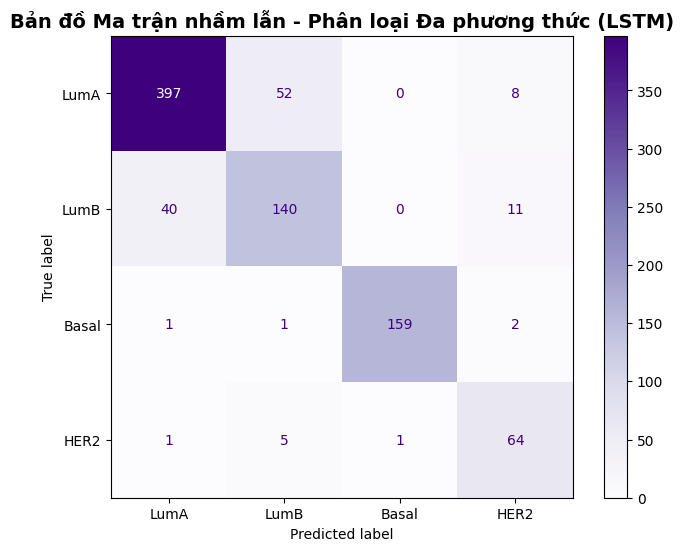

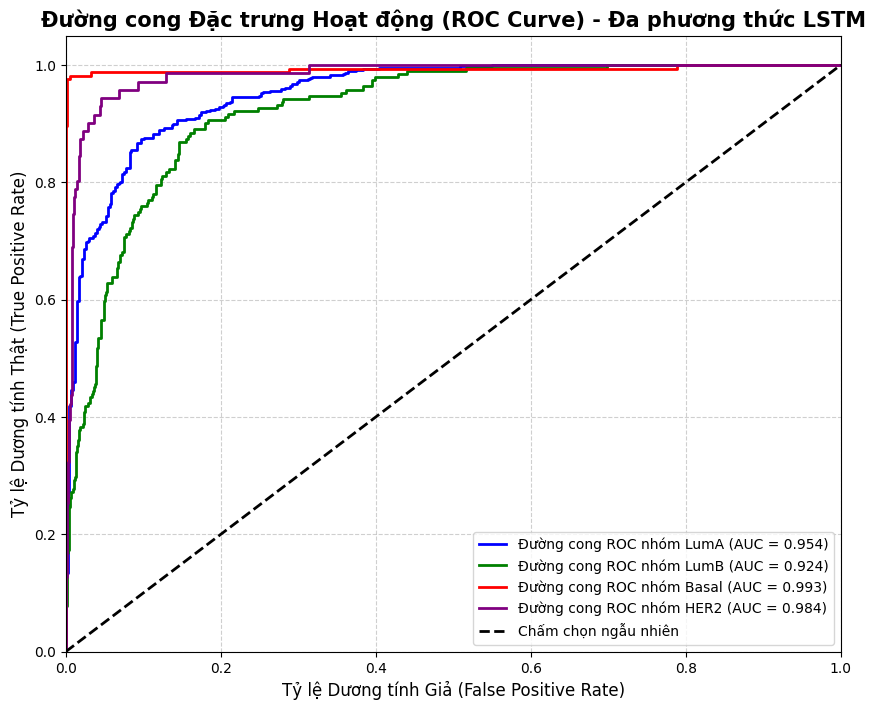

In [8]:
if len(valid_pids) > 0:
    # 1. VẼ CONFUSION MATRIX
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Purples', ax=ax, values_format='d')
    plt.title('Bản đồ Ma trận nhầm lẫn - Phân loại Đa phương thức (LSTM)', fontsize=14, fontweight='bold')
    plt.show()

    # 2. VẼ ROC CURVE CHO 4 CLASS (OVR)
    # Chuyển nhãn (0,1,2,3) thành One-Hot Encoding để vẽ ROC cho multiclass
    y_test_bin = label_binarize(best_global_labels, classes=[0, 1, 2, 3])
    y_score = np.array(best_global_probs)
    n_classes = y_test_bin.shape[1]

    fpr, tpr, roc_auc = dict(), dict(), dict()
    class_names = ['LumA', 'LumB', 'Basal', 'HER2']
    colors = ['blue', 'green', 'red', 'purple']

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, 
                 label=f'Đường cong ROC nhóm {class_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chấm chọn ngẫu nhiên')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontsize=12)
    plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontsize=12)
    plt.title('Đường cong Đặc trưng Hoạt động (ROC Curve) - Đa phương thức LSTM', fontsize=15, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()